In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv


# Import libraries****

In [2]:
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import ( LabelEncoder, OneHotEncoder, StandardScaler,    MinMaxScaler)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ( train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold)
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix,classification_report,roc_curve)
from sklearn.inspection import permutation_importance

In [3]:
file_path = "/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(file_path)

In [4]:
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# Dataset Overview¶

In [5]:
# Dataset Shape
print("Shape of Dataset:", df.shape)

Shape of Dataset: (1470, 35)


In [8]:
# Column Names
print("Columns:")
print(df.columns)

Columns:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [10]:
# Data Types
print("\nData Types:")
print(df.dtypes)


Data Types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWo

In [15]:
# Dataset Information
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel 

In [16]:
# Statistical Summary
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [17]:
# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole     

In [18]:
# Duplicate Rows
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


# EDA****

In [19]:
key_features = [
    'Age',
    'Gender',
    'MaritalStatus',
    'Education',
    'JobRole',
    'Department',
    'JobLevel',
    'OverTime',
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'WorkLifeBalance',
    'PerformanceRating',
    'YearsSinceLastPromotion',
    'MonthlyIncome',
    'Attrition'
]

df = df[key_features]
df.head()

,Age,Gender,MaritalStatus,Education,JobRole,Department,JobLevel,OverTime,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,PerformanceRating,YearsSinceLastPromotion,MonthlyIncome,Attrition
0,41,Female,Single,2,Sales Executive,Sales,2,Yes,4,2,1,3,0,5993,Yes
1,49,Male,Married,1,Research Scientist,Research & Development,2,No,2,3,3,4,1,5130,No
2,37,Male,Single,2,Laboratory Technician,Research & Development,1,Yes,3,4,3,3,0,2090,Yes
3,33,Female,Married,4,Research Scientist,Research & Development,1,Yes,3,4,3,3,3,2909,No
4,27,Male,Married,1,Laboratory Technician,Research & Development,1,No,2,1,3,3,2,3468,No


Attrition
No     1233
Yes     237
Name: count, dtype: int64


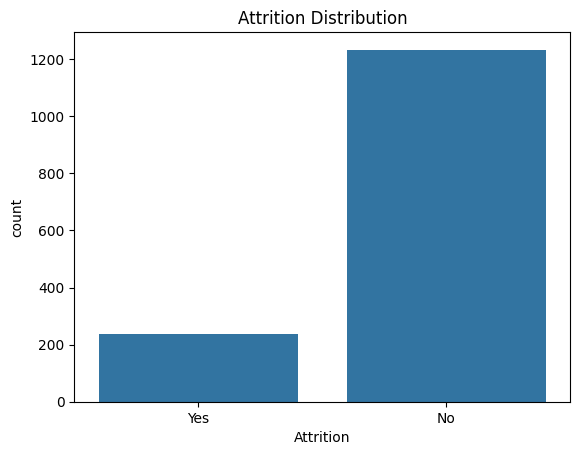

In [20]:
# Attrition Distribution
print(df['Attrition'].value_counts())

sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.show()

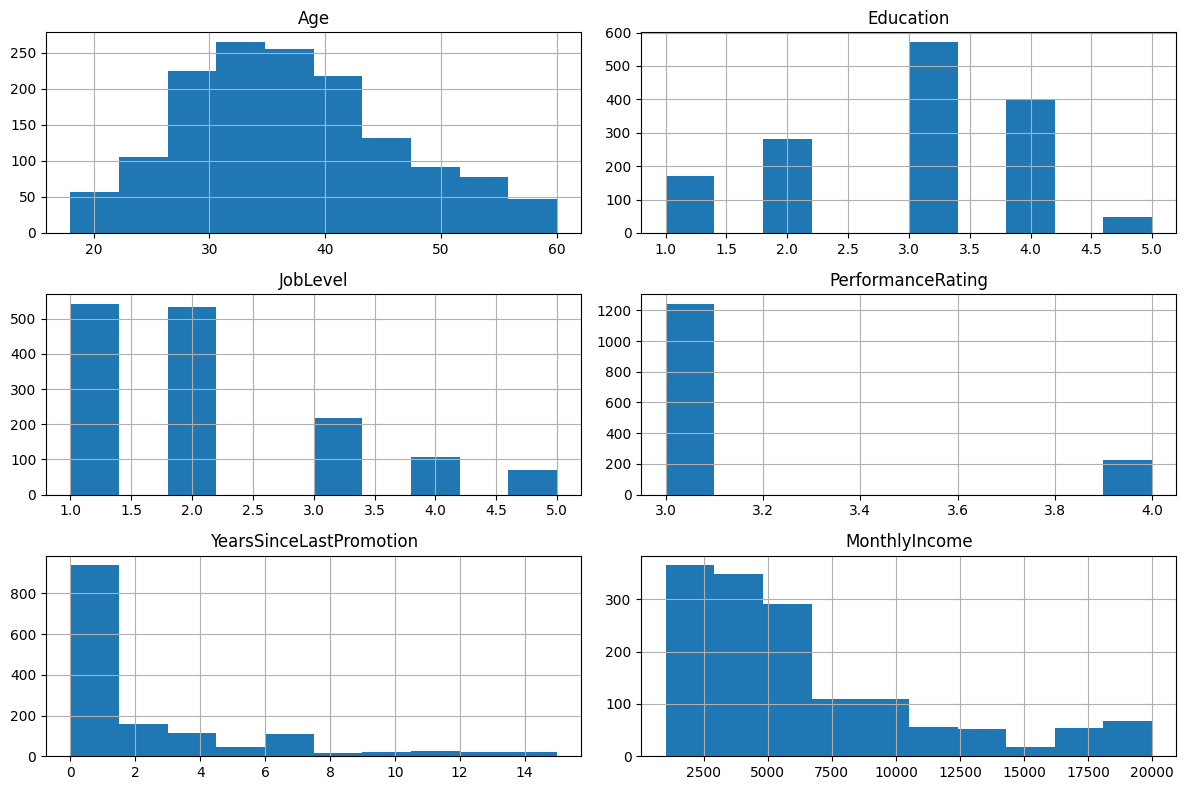

In [21]:
# Numerical Features Analysis
numerical_features = [
    'Age',
    'Education',
    'JobLevel',
    'PerformanceRating',
    'YearsSinceLastPromotion',
    'MonthlyIncome'
]

df[numerical_features].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

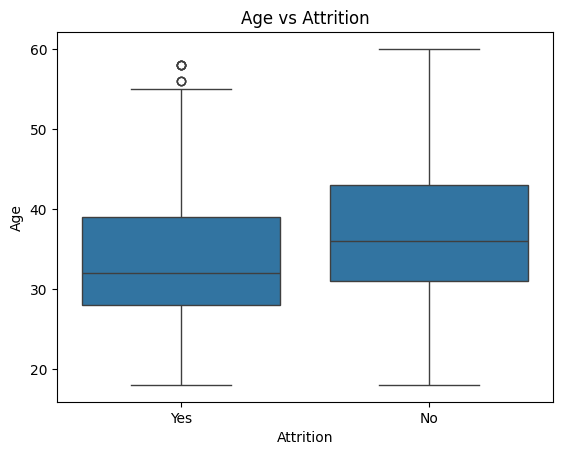

In [22]:
# 'Age vs Attrition
sns.boxplot(x='Attrition', y='Age', data=df)
plt.title('Age vs Attrition')
plt.show()

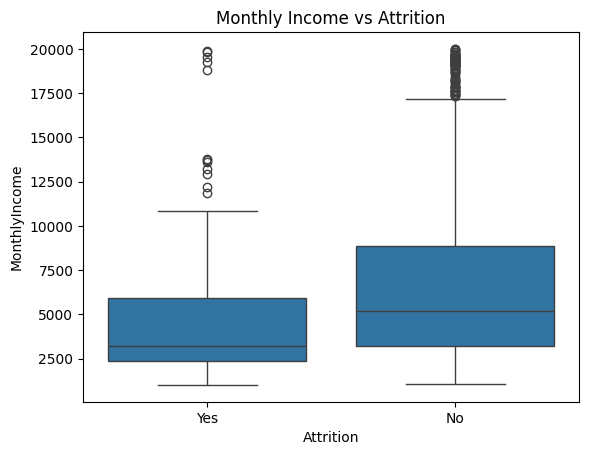

In [23]:
# Monthly Income vs Attrition
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income vs Attrition')
plt.show()

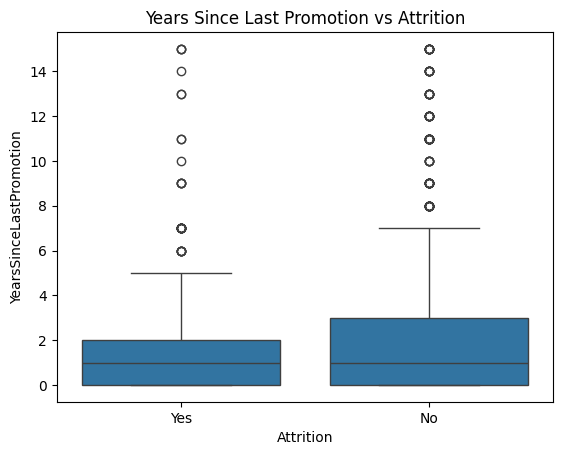

In [24]:
# Years Since Last Promotion vs Attrition
sns.boxplot(x='Attrition', y='YearsSinceLastPromotion', data=df)
plt.title('Years Since Last Promotion vs Attrition')
plt.show()

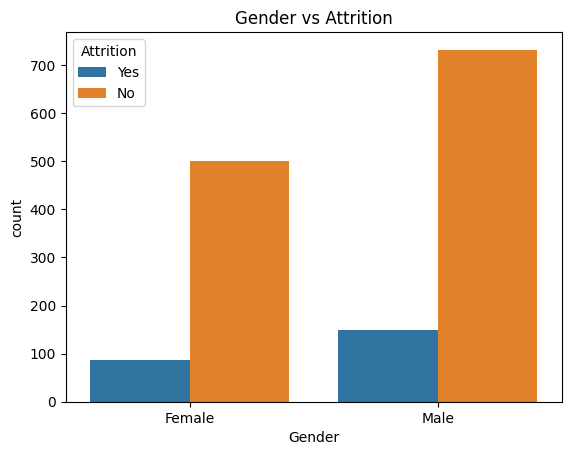

In [25]:
# Gender vs Attrition
sns.countplot(x='Gender', hue='Attrition', data=df)
plt.title('Gender vs Attrition')
plt.show()

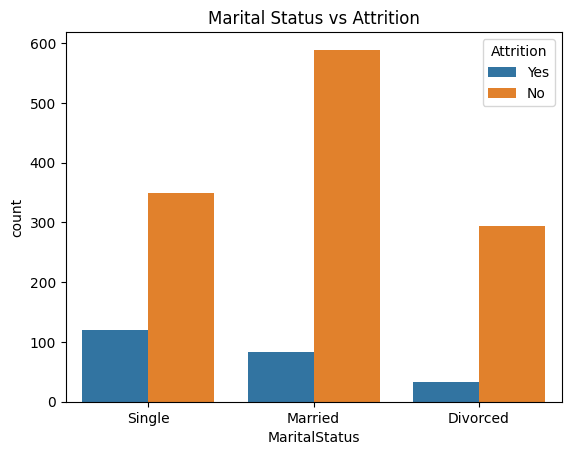

In [26]:
# Marital Status vs Attrition
sns.countplot(x='MaritalStatus', hue='Attrition', data=df)
plt.title('Marital Status vs Attrition')
plt.show()

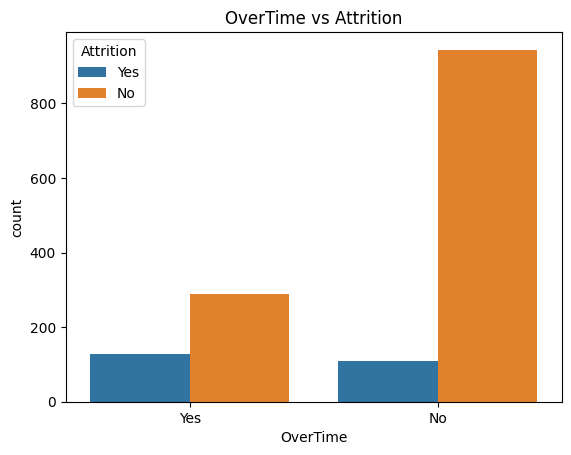

In [27]:
# OverTime vs Attrition
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title('OverTime vs Attrition')
plt.show()

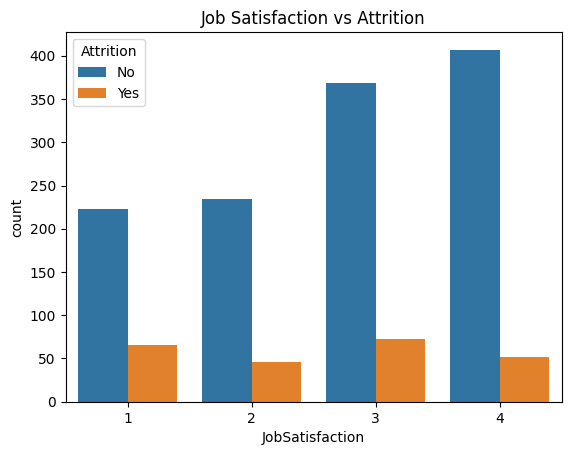

In [28]:
# Job Satisfaction vs Attrition
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)
plt.title('Job Satisfaction vs Attrition')
plt.show()

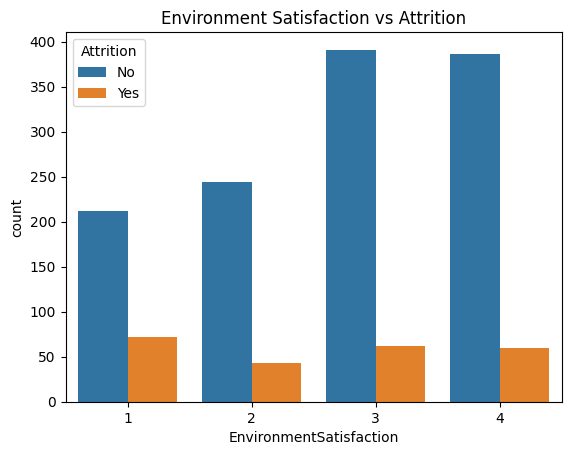

In [29]:
# Environment Satisfaction vs Attrition
sns.countplot(x='EnvironmentSatisfaction', hue='Attrition', data=df)
plt.title('Environment Satisfaction vs Attrition')
plt.show()

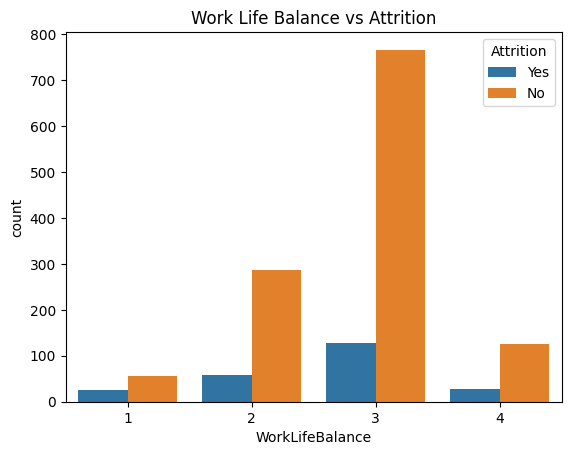

In [30]:
# Work Life Balance vs Attrition
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df)
plt.title('Work Life Balance vs Attrition')
plt.show()

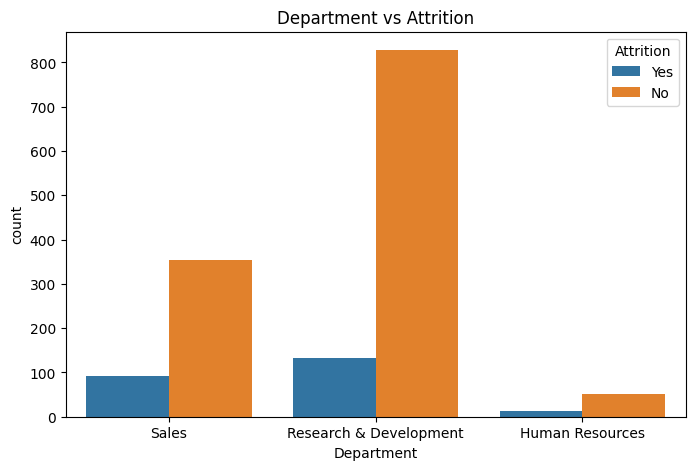

In [31]:
# Department vs Attrition
plt.figure(figsize=(8,5))

sns.countplot(x='Department', hue='Attrition', data=df)

plt.title('Department vs Attrition')
plt.show()

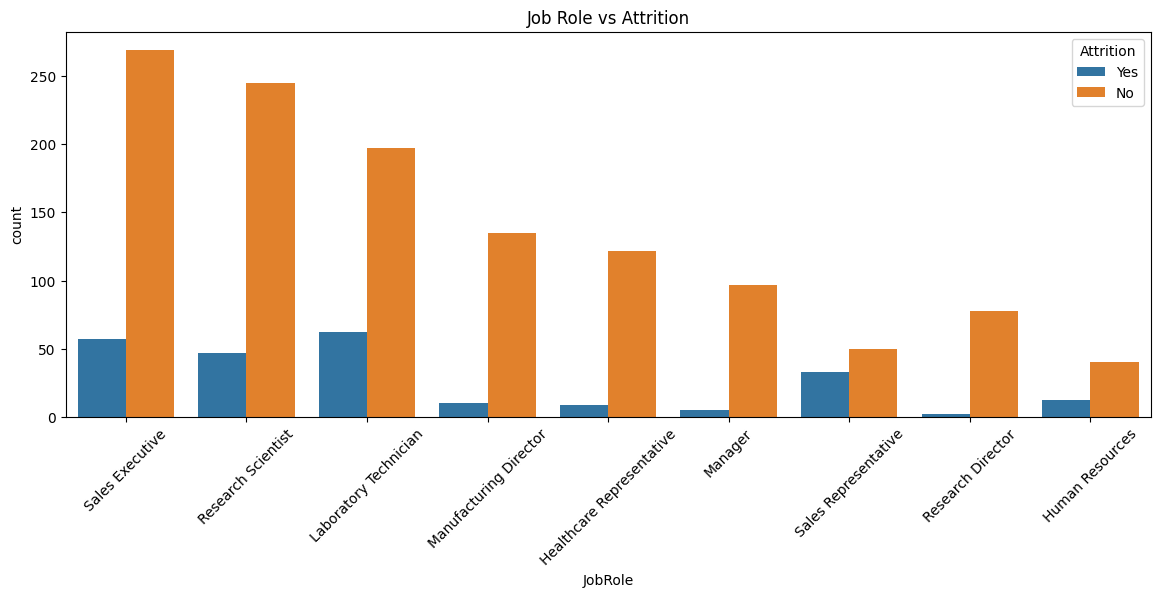

In [32]:
# Job Role vs Attrition
plt.figure(figsize=(14,5))

sns.countplot(x='JobRole', hue='Attrition', data=df)

plt.xticks(rotation=45)
plt.title('Job Role vs Attrition')
plt.show()

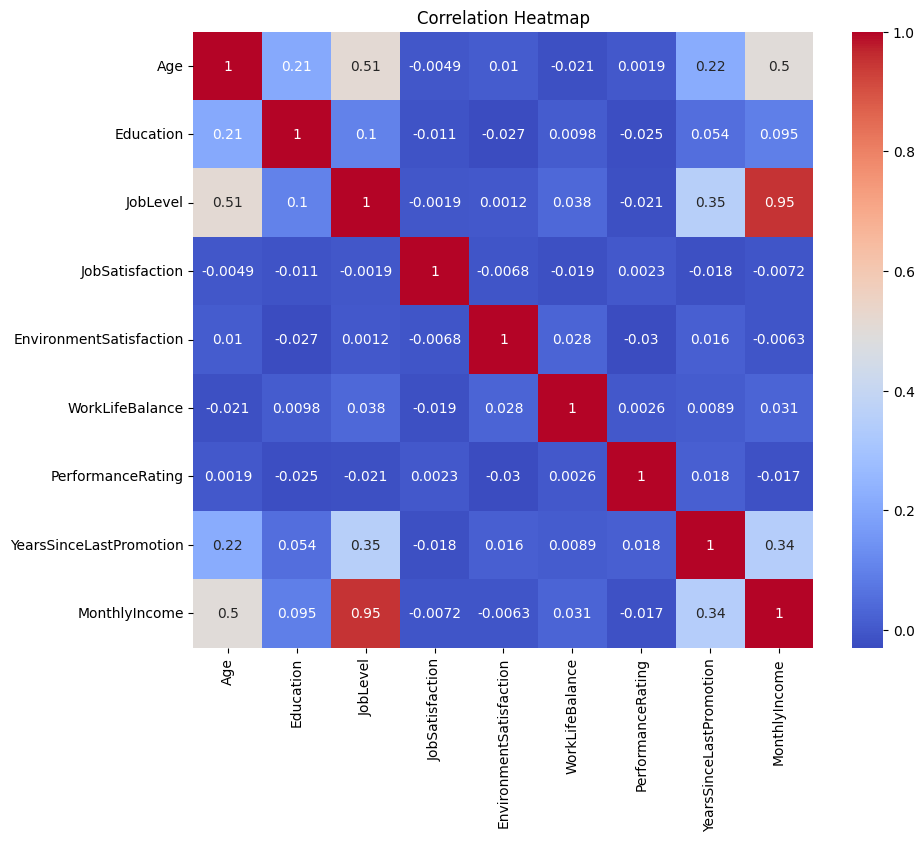

In [33]:
# Correlation Heatmap
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

# check how many outliers exist****

In [36]:
# Check Outliers using IQR

outlier_cols = ['Age', 'MonthlyIncome', 'YearsSinceLastPromotion']

for col in outlier_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\n{col}")
    print("-" * 30)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))


Age
------------------------------
Lower Bound: 10.5
Upper Bound: 62.5
Number of Outliers: 0

MonthlyIncome
------------------------------
Lower Bound: -5291.0
Upper Bound: 16581.0
Number of Outliers: 114

YearsSinceLastPromotion
------------------------------
Lower Bound: -4.5
Upper Bound: 7.5
Number of Outliers: 107


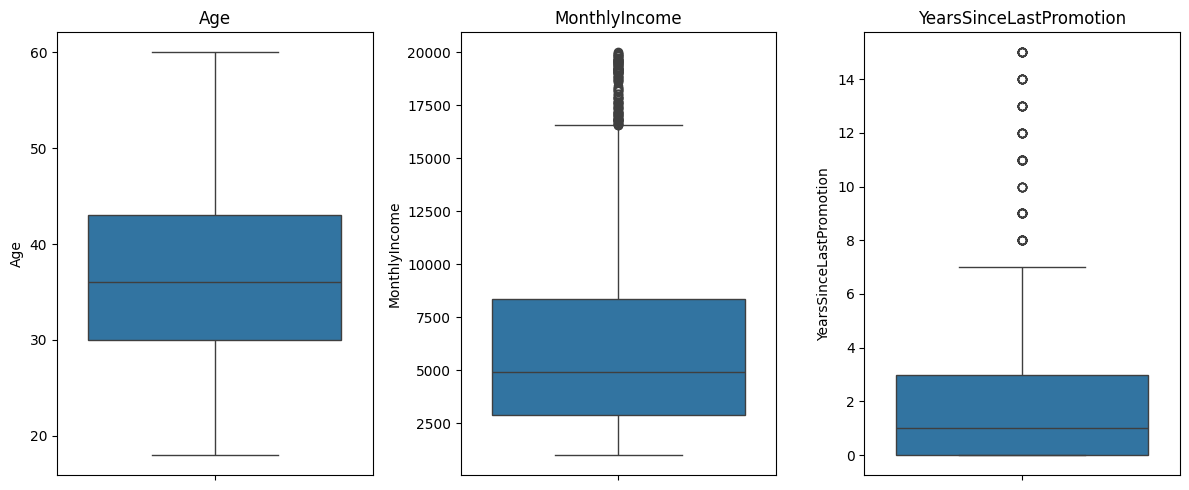

In [37]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
sns.boxplot(y=df['Age'])
plt.title('Age')

plt.subplot(1,3,2)
sns.boxplot(y=df['MonthlyIncome'])
plt.title('MonthlyIncome')

plt.subplot(1,3,3)
sns.boxplot(y=df['YearsSinceLastPromotion'])
plt.title('YearsSinceLastPromotion')

plt.tight_layout()
plt.show()

In [38]:
# MonthlyIncome Outliers

Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

monthly_outliers = df[df['MonthlyIncome'] > upper]

print("Number of MonthlyIncome Outliers:", len(monthly_outliers))

monthly_outliers[['MonthlyIncome','JobRole','JobLevel','Attrition']].head(20)

Number of MonthlyIncome Outliers: 114


,MonthlyIncome,JobRole,JobLevel,Attrition
25,19094,Manager,5,No
29,18947,Manager,5,No
45,19545,Research Director,5,Yes
62,18740,Research Director,5,No
105,18844,Manager,5,No
106,18172,Research Director,5,No
112,17328,Manager,4,No
119,16959,Manager,4,No
123,19537,Research Director,5,No
147,17181,Manager,4,No


In [40]:
# YearsSinceLastPromotion Outliers

Q1 = df['YearsSinceLastPromotion'].quantile(0.25)
Q3 = df['YearsSinceLastPromotion'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

promotion_outliers = df[df['YearsSinceLastPromotion'] > upper]

print("Number of Promotion Outliers:", len(promotion_outliers))

promotion_outliers[['YearsSinceLastPromotion','JobRole','Attrition']].head(20)

Number of Promotion Outliers: 107


,YearsSinceLastPromotion,JobRole,Attrition
15,8,Manufacturing Director,No
45,15,Research Director,Yes
46,8,Sales Executive,No
55,8,Research Director,No
61,9,Laboratory Technician,No
62,13,Research Director,No
64,12,Healthcare Representative,No
88,10,Healthcare Representative,No
90,11,Healthcare Representative,No
93,9,Healthcare Representative,No


Outlier analysis was conducted on MonthlyIncome and YearsSinceLastPromotion using the Interquartile Range (IQR) method. A total of 114 outliers were identified in MonthlyIncome and 107 outliers in YearsSinceLastPromotion. Examination of these records revealed that the majority belonged to senior positions such as Managers and Research Directors with higher job levels and salaries. Similarly, employees with large values for YearsSinceLastPromotion represented long-tenured employees who had not received promotions for extended periods.

Since these observations reflect genuine employee characteristics rather than data entry errors, they were retained in the dataset. Removing them could result in the loss of important business information and negatively affect the predictive performance of the attrition models.

In [41]:


# CHANGE PATH IF NEEDED
DATA_PATH = '/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv'

df = pd.read_csv(DATA_PATH).copy()

print("Dataset Loaded:", df.shape)


# 1. SAFE COLUMN CHECK (PREVENT KEYERROR)


required_cols = [
    'Age','Gender','MaritalStatus','Education','JobRole','Department',
    'JobLevel','OverTime','JobSatisfaction','EnvironmentSatisfaction',
    'WorkLifeBalance','PerformanceRating','YearsSinceLastPromotion',
    'MonthlyIncome','Attrition'
]

missing = [col for col in required_cols if col not in df.columns]

if len(missing) > 0:
    raise ValueError(f"Missing columns in dataset: {missing}")


# 2. SELECT FEATURES


df = df[required_cols].copy()


# 3. TARGET ENCODING (SAFE)

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# 4. HANDLE BINARY COLUMNS SAFELY

le = LabelEncoder()

for col in ['Gender', 'OverTime']:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# 5. ONE HOT ENCODING (SAFE)

cat_cols = ['MaritalStatus', 'JobRole', 'Department']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# ==========================================
# 6. SPLIT X & Y (SAFE CHECK)
# ==========================================

if 'Attrition' not in df.columns:
    raise ValueError("Target column missing after preprocessing")

X = df.drop('Attrition', axis=1)
y = df['Attrition']

print("X Shape:", X.shape)
print("y Shape:", y.shape)


# 7. TRAIN TEST SPLIT (SAFE STRATIFY CHECK)

if y.nunique() < 2:
    raise ValueError("Target has only one class")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


# 8. FEATURE SCALING (SAFE)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Done")

# 9. SMOTE (ONLY IF IMBALANCE EXISTS)

if y_train.value_counts().min() > 1:

    smote = SMOTE(random_state=42)

    X_train_smote, y_train_smote = smote.fit_resample(
        X_train_scaled,
        y_train
    )

    print("Before SMOTE:\n", y_train.value_counts())
    print("After SMOTE:\n", pd.Series(y_train_smote).value_counts())

else:
    print("SMOTE skipped (not enough samples)")
    X_train_smote, y_train_smote = X_train_scaled, y_train


# FINAL OUTPUT READY FOR MODELS

print("\nPIPELINE SUCCESSFULLY COMPLETED 🚀")
print("Ready datasets:")
print("X_train_smote, y_train_smote")
print("X_test_scaled, y_test")

Dataset Loaded: (1470, 35)
X Shape: (1470, 23)
y Shape: (1470,)
Train Shape: (1176, 23)
Test Shape: (294, 23)
Scaling Done
Before SMOTE:
 Attrition
0    986
1    190
Name: count, dtype: int64
After SMOTE:
 Attrition
0    986
1    986
Name: count, dtype: int64

PIPELINE SUCCESSFULLY COMPLETED 🚀
Ready datasets:
X_train_smote, y_train_smote
X_test_scaled, y_test


# MODEL TRAINING

In [42]:
# DECISION TREE + GRIDSEARCH + 5-FOLD CV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=42)

dt_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    dt,
    dt_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

dt_grid.fit(X_train_smote, y_train_smote)

print("Best DT Params:", dt_grid.best_params_)
print("Best DT Score:", dt_grid.best_score_)

Best DT Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best DT Score: 0.8494540750270113


In [43]:
# XGBOOST + GRIDSEARCH + 5-FOLD CV
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss', random_state=42)

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

xgb_grid.fit(X_train_smote, y_train_smote)

print("Best XGB Params:", xgb_grid.best_params_)
print("Best XGB Score:", xgb_grid.best_score_)

Best XGB Params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best XGB Score: 0.8737316918556056


In [44]:
# LOGISTIC REGRESSION + GRIDSEARCH + 5-FOLD CV

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lr = LogisticRegression(max_iter=1000)

lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

lr_grid = GridSearchCV(
    lr,
    lr_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

lr_grid.fit(X_train_smote, y_train_smote)

print("Best LR Params:", lr_grid.best_params_)
print("Best LR Score:", lr_grid.best_score_)

Best LR Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best LR Score: 0.7611297256003512


In [45]:
# RANDOM FOREST + GRIDSEARCH + 5-FOLD CV

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train_smote, y_train_smote)

print("Best RF Params:", rf_grid.best_params_)
print("Best RF Score:", rf_grid.best_score_)

Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RF Score: 0.9221685974810399


In [46]:
# MODEL COMPARISON TABLE (FINAL SELECTION)

import pandas as pd

results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    
    "Best F1 Score (CV)": [
        lr_grid.best_score_,
        dt_grid.best_score_,
        rf_grid.best_score_,
        xgb_grid.best_score_
    ]
}

results_df = pd.DataFrame(results)

# Sort by performance
results_df = results_df.sort_values(by="Best F1 Score (CV)", ascending=False)

print(results_df)

                 Model  Best F1 Score (CV)
2        Random Forest            0.922169
3              XGBoost            0.873732
1        Decision Tree            0.849454
0  Logistic Regression            0.761130


In [49]:
# BEST MODEL SELECTION

best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

if best_model_name == "Logistic Regression":
    best_model = lr_grid.best_estimator_

elif best_model_name == "Decision Tree":
    best_model = dt_grid.best_estimator_

elif best_model_name == "Random Forest":
    best_model = rf_grid.best_estimator_

else:
    best_model = xgb_grid.best_estimator_

print("Best model selected successfully ")

Best Model: Random Forest
Best model selected successfully 


In [50]:
# FINAL EVALUATION
from sklearn.metrics import classification_report, accuracy_score

y_pred = best_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8503401360544217
              precision    recall  f1-score   support

           0       0.87      0.96      0.92       247
           1       0.57      0.28      0.37        47

    accuracy                           0.85       294
   macro avg       0.72      0.62      0.64       294
weighted avg       0.83      0.85      0.83       294



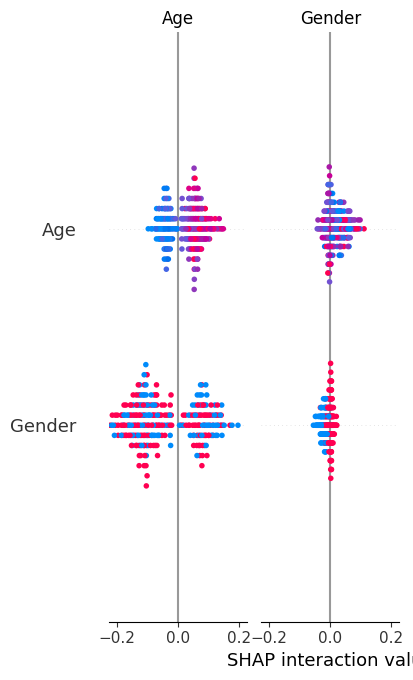

In [51]:
# SHAP EXPLAINABILITY (TOP ATTRITION FACTORS)
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

“Although the model achieved 85% accuracy, performance on the minority class (attrition = Yes) is weaker, with recall of 0.28, indicating difficulty in identifying employees likely to leave.”

# HIGHER RECALL (HR-READY MODEL)

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_hr = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",   # IMPORTANT FOR RECALL
    random_state=42
)

rf_hr.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [53]:
y_proba = rf_hr.predict_proba(X_test_scaled)[:, 1]

In [54]:
y_pred_recall = (y_proba > 0.25).astype(int)

In [55]:
# Train model WITHOUT SMOTE
from sklearn.ensemble import RandomForestClassifier

rf_no_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"   # keeps imbalance handling
)

# TRAIN on ORIGINAL (not SMOTE) data
rf_no_smote.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [56]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_recall))
print("\nClassification Report:\n", classification_report(y_test, y_pred_recall))

Confusion Matrix:
 [[216  31]
 [ 28  19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88       247
           1       0.38      0.40      0.39        47

    accuracy                           0.80       294
   macro avg       0.63      0.64      0.64       294
weighted avg       0.80      0.80      0.80       294



In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ✅ Single model, trained on SMOTE data (already created earlier)
rf_hr = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)

# ✅ Train on SMOTE-balanced data
rf_hr.fit(X_train_smote, y_train_smote)

# ✅ Get probabilities on the test set
y_proba = rf_hr.predict_proba(X_test_scaled)[:, 1]

# ✅ Lower threshold to boost recall for class 1
y_pred_recall = (y_proba > 0.25).astype(int)

# ✅ Evaluate the SAME model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_recall))
print("\nClassification Report:\n", classification_report(y_test, y_pred_recall))

Confusion Matrix:
 [[183  64]
 [ 17  30]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.74      0.82       247
           1       0.32      0.64      0.43        47

    accuracy                           0.72       294
   macro avg       0.62      0.69      0.62       294
weighted avg       0.82      0.72      0.76       294



In [59]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.combine import SMOTETomek

# ✅ STEP 1: Better balancing — SMOTETomek cleans noisy border samples too
smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train_scaled, y_train)

print("After SMOTETomek:", pd.Series(y_train_smt).value_counts().to_dict())

# ✅ STEP 2: Build 3 strong models with class_weight="balanced"
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# ✅ STEP 3: Soft Voting Ensemble (combines all 3)
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('lr', lr)],
    voting='soft'
)

# ✅ STEP 4: Train on SMOTETomek balanced data
ensemble.fit(X_train_smt, y_train_smt)
print("Ensemble trained ✅")

# ✅ STEP 5: Find best threshold automatically (no guessing)
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score

y_proba = ensemble.predict_proba(X_test_scaled)[:, 1]

best_thresh = 0.5
best_f1 = 0.0

print("\nThreshold Sweep:")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")

for t in np.arange(0.10, 0.60, 0.05):
    preds = (y_proba >= t).astype(int)
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds)
    f = f1_score(y_test, preds)
    print(f"{t:>10.2f} {p:>10.3f} {r:>10.3f} {f:>10.3f}")
    if f > best_f1:
        best_f1 = f
        best_thresh = t

print(f"\n✅ Best Threshold: {best_thresh:.2f}  |  Best F1: {best_f1:.3f}")

# ✅ STEP 6: Final predictions with best threshold
y_pred_final = (y_proba >= best_thresh).astype(int)

# ✅ STEP 7: Evaluate
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))

After SMOTETomek: {0: 979, 1: 979}
Ensemble trained ✅

Threshold Sweep:
 Threshold  Precision     Recall         F1
      0.10      0.203      0.936      0.333
      0.15      0.226      0.851      0.357
      0.20      0.276      0.851      0.417
      0.25      0.315      0.851      0.460
      0.30      0.351      0.702      0.468
      0.35      0.377      0.617      0.468
      0.40      0.414      0.511      0.457
      0.45      0.417      0.426      0.421
      0.50      0.486      0.362      0.415
      0.55      0.571      0.340      0.427

✅ Best Threshold: 0.30  |  Best F1: 0.468

Confusion Matrix:
 [[186  61]
 [ 14  33]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.75      0.83       247
           1       0.35      0.70      0.47        47

    accuracy                           0.74       294
   macro avg       0.64      0.73      0.65       294
weighted avg       0.84      0.74      0.77       294



# Prediction

In [60]:
import joblib
import pandas as pd
import numpy as np

# ================================================================
# STEP 1: SAVE THE MODEL & SCALER (so you don't retrain every time)
# ================================================================
joblib.dump(ensemble, 'attrition_model.pkl')
joblib.dump(scaler,   'attrition_scaler.pkl')
print("✅ Model and scaler saved!")

# ================================================================
# STEP 2: LOAD THEM BACK (use this in future sessions)
# ================================================================
model  = joblib.load('attrition_model.pkl')
scaler = joblib.load('attrition_scaler.pkl')
print("✅ Model and scaler loaded!")

# ================================================================
# STEP 3: PREDICT ON A SINGLE NEW EMPLOYEE
# ================================================================

# Fill in real values for a new employee
new_employee = pd.DataFrame([{
    'Age': 34,
    'Gender': 1,                    # 1=Male, 0=Female
    'Education': 3,
    'JobLevel': 2,
    'OverTime': 1,                  # 1=Yes, 0=No
    'JobSatisfaction': 2,
    'EnvironmentSatisfaction': 2,
    'WorkLifeBalance': 2,
    'PerformanceRating': 3,
    'YearsSinceLastPromotion': 5,
    'MonthlyIncome': 3500,

    # One-hot encoded columns — set 1 for the matching category, 0 for rest
    'MaritalStatus_Married': 0,
    'MaritalStatus_Single': 1,

    'JobRole_Human Resources': 0,
    'JobRole_Laboratory Technician': 1,
    'JobRole_Manager': 0,
    'JobRole_Manufacturing Director': 0,
    'JobRole_Research Director': 0,
    'JobRole_Research Scientist': 0,
    'JobRole_Sales Executive': 0,
    'JobRole_Sales Representative': 0,

    'Department_Research & Development': 1,
    'Department_Sales': 0,
}])

# ✅ Make sure columns match training data exactly
new_employee = new_employee.reindex(columns=X.columns, fill_value=0)

# ✅ Scale using the same scaler
new_scaled = scaler.transform(new_employee)

# ✅ Predict probability
proba = model.predict_proba(new_scaled)[:, 1][0]

# ✅ Apply the same best threshold found earlier
prediction = int(proba >= best_thresh)

print(f"\n--- Single Employee Prediction ---")
print(f"Attrition Probability : {proba:.2%}")
print(f"Prediction            : {'⚠️  WILL LEAVE' if prediction == 1 else '✅ WILL STAY'}")

# ================================================================
# STEP 4: PREDICT ON MULTIPLE EMPLOYEES (batch)
# ================================================================

# Predict on your entire test set with probability + label
results_df = X_test.copy()
results_df['Attrition_Actual']      = y_test.values
results_df['Attrition_Probability'] = model.predict_proba(X_test_scaled)[:, 1]
results_df['Attrition_Predicted']   = (results_df['Attrition_Probability'] >= best_thresh).astype(int)
results_df['Risk_Level']            = pd.cut(
    results_df['Attrition_Probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['🟢 Low', '🟡 Medium', '🔴 High']
)

print("\n--- Batch Predictions (first 10 rows) ---")
print(results_df[['Attrition_Probability', 'Attrition_Predicted',
                   'Attrition_Actual', 'Risk_Level']].head(10).to_string())

# ================================================================
# STEP 5: HIGH RISK EMPLOYEES REPORT
# ================================================================

high_risk = results_df[results_df['Risk_Level'] == '🔴 High']
print(f"\n⚠️  High Risk Employees: {len(high_risk)} out of {len(results_df)}")
print(high_risk[['Attrition_Probability', 'Attrition_Predicted', 'Attrition_Actual']].head(10).to_string())

# Save full predictions to CSV
results_df.to_csv('attrition_predictions.csv', index=False)
print("\n✅ All predictions saved to attrition_predictions.csv")

✅ Model and scaler saved!
✅ Model and scaler loaded!

--- Single Employee Prediction ---
Attrition Probability : 71.14%
Prediction            : ⚠️  WILL LEAVE

--- Batch Predictions (first 10 rows) ---
      Attrition_Probability  Attrition_Predicted  Attrition_Actual Risk_Level
1061               0.527575                    1                 0   🟡 Medium
891                0.100598                    0                 0      🟢 Low
456                0.080611                    0                 0      🟢 Low
922                0.073243                    0                 0      🟢 Low
69                 0.323761                    1                 1   🟡 Medium
1164               0.273834                    0                 0      🟢 Low
406                0.135115                    0                 0      🟢 Low
1330               0.106153                    0                 0      🟢 Low
1232               0.067870                    0                 0      🟢 Low
1311              